In [142]:
import pandas as pd
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report

In [12]:
file_path_to_data_2d = 'data\data_2d.csv'
file_path_to_mnist = 'data\mnist.csv'

In [76]:
data_2d = pd.read_csv(file_path_to_data_2d,header=None)
mnist = pd.read_csv(file_path_to_mnist,header=None)

In [114]:
X_2d = data_2d.drop(columns=0)
y_2d = data_2d[0]

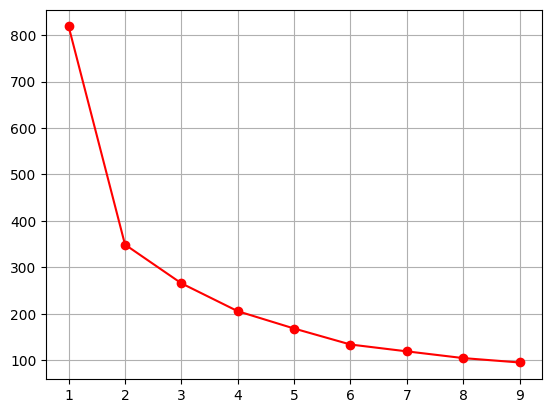

In [120]:
inertia_value_2d = []

for i in range(1,10):
    kmeans_2d = KMeans(n_clusters= i,random_state=42)
    y_2d_km = kmeans_2d.fit_predict(X_2d)
    inertia_value_2d.append(kmeans_2d.inertia_)


plt.plot(range(1,10),inertia_value_2d,c='r',marker = 'o')
plt.grid()

Згідно графіку "ліктя" чітко видно, що оптимальна кількість кластерів є 2.

In [121]:
kmeans_2d = KMeans(n_clusters = 2,random_state=42)
y_2d_km = kmeans_2d.fit_predict(X_2d)

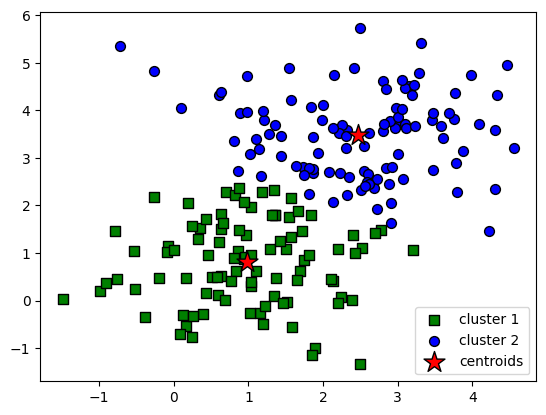

In [ ]:
plt.scatter(X_2d.iloc[y_2d_km == 0,0], X_2d.iloc[y_2d_km == 0,1],
            s = 50,c = 'g',
            marker='s',edgecolors= 'black',
            label = 'cluster 1')

plt.scatter(X_2d.iloc[y_2d_km == 1,0],X_2d.iloc[y_2d_km == 1,1],
            s = 50,c = 'b',
            marker='o',edgecolors= 'black',
            label = 'cluster 2')

plt.scatter(kmeans_2d.cluster_centers_[:,0],kmeans_2d.cluster_centers_[:,1],
            s = 250,c = 'r',
            marker='*',edgecolors= 'black',
            label = 'centroids')
plt.legend()
plt.show()

In [125]:
X_mnist = mnist.drop(columns=0)
y_mnist = mnist[0]

In [126]:
X_mnist_norm = StandardScaler().fit_transform(X_mnist)

In [127]:
pca = PCA(n_components=2)
pca_mnist = pca.fit_transform(X_mnist_norm)

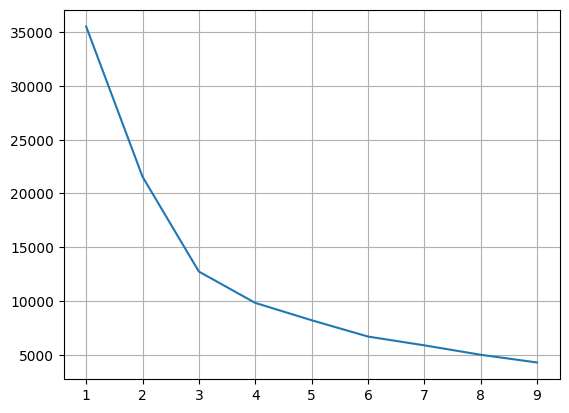

In [141]:
inertia_value_mnist = []

for i in range(1,10):
    kmeans_mnist = KMeans(n_clusters=i,random_state=42)
    y_mnist_km = kmeans_mnist.fit_predict(pca_mnist)
    inertia_value_mnist.append(kmeans_mnist.inertia_)

plt.plot(range(1,10),inertia_value_mnist)
plt.grid()

Згідно графіку "ліктя" чітко видно, що оптимальна кількість кластерів є 3.

In [136]:
kmeans_mnist = KMeans(n_clusters=3,random_state=42)
y_mnist_km = kmeans_mnist.fit_predict(pca_mnist)

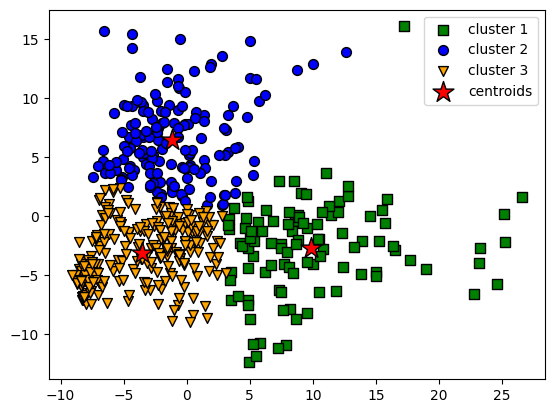

In [139]:
plt.scatter(pca_mnist[y_mnist_km == 0,0], pca_mnist[y_mnist_km == 0,1],
            s = 50,c = 'g',
            marker='s',edgecolors= 'black',
            label = 'cluster 1')

plt.scatter(pca_mnist[y_mnist_km == 1,0],pca_mnist[y_mnist_km == 1,1],
            s = 50,c = 'b',
            marker='o',edgecolors= 'black',
            label = 'cluster 2')

plt.scatter(pca_mnist[y_mnist_km == 2,0],pca_mnist[y_mnist_km == 2,1],
            s = 50,c = 'orange',
            marker='v',edgecolors= 'black',
            label = 'cluster 3')

plt.scatter(kmeans_mnist.cluster_centers_[:,0],kmeans_mnist.cluster_centers_[:,1],
            s = 250,c = 'r',
            marker='*',edgecolors= 'black',
            label = 'centroids')
plt.legend()
plt.show()